In [399]:
import json
import matplotlib.pyplot as plt
import seaborn as sn
import pandas as pd
import numpy as np

from tqdm import tqdm

from bot.utilities import classify_message

In [4]:
with open('data/relocation_it_chat.json', 'r') as f:
    data = json.load(f)

data

{'name': 'Релокейшн - IT',
 'type': 'public_supergroup',
 'id': 1751549303,
 'messages': [{'id': 1,
   'type': 'service',
   'date': '2022-03-10T13:29:04',
   'date_unixtime': '1646908144',
   'actor': 'Релокейшн - IT',
   'actor_id': 'channel1751549303',
   'action': 'migrate_from_group',
   'title': 'Релокейшн - IT',
   'text': '',
   'text_entities': []},
  {'id': 2,
   'type': 'message',
   'date': '2022-03-10T13:30:18',
   'date_unixtime': '1646908218',
   'from': 'Roman Pavlovsky',
   'from_id': 'user12041300',
   'text': [{'type': 'mention', 'text': '@wza_kmx'}, ' ui ux'],
   'text_entities': [{'type': 'mention', 'text': '@wza_kmx'},
    {'type': 'plain', 'text': ' ui ux'}]},
  {'id': 3,
   'type': 'message',
   'date': '2022-03-10T13:31:03',
   'date_unixtime': '1646908263',
   'from': 'Vadim Isaev',
   'from_id': 'user3019228',
   'text': [{'type': 'link',
     'text': 'https://m.facebook.com/story.php?story_fbid=1689993638018832&id=100010246350838'},
    ' статья по теме'],
 

## 1) messages that contain '?'

In [173]:
ids_has_question_mark = []

def extract_text(message) -> str:
    text = message.get('text')
    if isinstance(text, str):
        return text

    # if we have a link => ignore
    elif isinstance(text, list):
        full_text = []
        for txt in text:
            if isinstance(txt, dict):
                if txt.get('type') == 'link': continue
                full_text.append(txt.get('text', ''))
            else:
                full_text.append(txt)
        return ''.join(full_text)
    return ''


for message in data['messages']:
    cleaned_text = extract_text(message)
    if '?' in cleaned_text:
        ids_has_question_mark.append(message['id'])

#print(*ids_has_question_mark)
len(ids_has_question_mark)

14733

## 2) messages with '?' that have been answered

In [176]:
id_to_index = {message['id']: index for index, message in enumerate(data['messages'])}

question_to_replies_ids = {question_idx: [] for question_idx in ids_has_question_mark}

for message in data['messages']:
    prev_id = message.get('reply_to_message_id')
    if prev_id is None: continue

    if prev_id in question_to_replies_ids:
        question_to_replies_ids[prev_id].append(message['id'])

In [178]:
print(f'len: {len(question_to_replies_ids)}\n')

for key, val in question_to_replies_ids.items():
    print(f'{key}   :   {val}')

len: 14733

6   :   [9, 30]
12   :   [13]
14   :   []
18   :   [19, 20]
30   :   [32]
33   :   [34, 35]
34   :   [37]
39   :   [42]
60   :   []
64   :   [65]
72   :   []
78   :   []
94   :   []
128   :   []
132   :   []
135   :   [136]
140   :   []
150   :   [152]
171   :   []
172   :   []
175   :   [177]
177   :   []
179   :   []
193   :   []
196   :   []
203   :   []
255   :   [257]
296   :   []
301   :   [302, 342]
302   :   [303]
310   :   [312]
330   :   []
352   :   [416]
446   :   [468, 533]
464   :   []
474   :   []
548   :   [3229, 3234]
557   :   []
594   :   []
595   :   [599, 604]
598   :   [600]
603   :   []
630   :   [631, 635, 636]
635   :   []
659   :   [660]
661   :   [665]
726   :   []
763   :   []
764   :   [765]
780   :   [781]
783   :   [798]
798   :   [802]
810   :   [811, 816]
824   :   [825, 838, 925, 975]
830   :   [834, 839, 960]
834   :   [835]
836   :   [837]
853   :   [855, 860]
909   :   [929]
947   :   [948]
951   :   [952, 954]
954   :   [955]
956   :   

In [180]:
question_to_replies_ids_cleaned = {}

for question_id, replies in question_to_replies_ids.items():
    if replies: question_to_replies_ids_cleaned[question_id] = replies

In [182]:
print(f'len: {len(question_to_replies_ids_cleaned)}\n')

for key, val in question_to_replies_ids_cleaned.items():
    print(f'{key}   :   {val}')

len: 9386

6   :   [9, 30]
12   :   [13]
18   :   [19, 20]
30   :   [32]
33   :   [34, 35]
34   :   [37]
39   :   [42]
64   :   [65]
135   :   [136]
150   :   [152]
175   :   [177]
255   :   [257]
301   :   [302, 342]
302   :   [303]
310   :   [312]
352   :   [416]
446   :   [468, 533]
548   :   [3229, 3234]
595   :   [599, 604]
598   :   [600]
630   :   [631, 635, 636]
659   :   [660]
661   :   [665]
764   :   [765]
780   :   [781]
783   :   [798]
798   :   [802]
810   :   [811, 816]
824   :   [825, 838, 925, 975]
830   :   [834, 839, 960]
834   :   [835]
836   :   [837]
853   :   [855, 860]
909   :   [929]
947   :   [948]
951   :   [952, 954]
954   :   [955]
956   :   [957]
1030   :   [1031]
1048   :   [1049, 1052]
1054   :   [1055, 1057, 1066]
1074   :   [1076, 1077, 1078]
1097   :   [1099]
1126   :   [1128, 1135]
1152   :   [1153, 1154, 1162]
1153   :   [1155]
1185   :   [1186]
1187   :   [1190]
1189   :   [1191]
1228   :   [1242, 1428]
1243   :   [1244]
1259   :   [1260]
1269   : 

## 3) questions classfication

In [195]:
def get_text_by_id(message_id) -> str:
    index = id_to_index[message_id]
    return extract_text(data['messages'][index])

rows = []

for message_id in question_to_replies_ids_cleaned.keys():
    rows.append({'id': message_id, 'text': get_text_by_id(message_id), 'label': np.nan})

df = pd.DataFrame(rows, columns=['id', 'text', 'label'])
df

,id,text,label
0,6,"Ребят,а кто-то может сориентировать по цене од...",NaN
1,12,Как быстро вообще находится квартира?,NaN
2,18,"Кто нибудь знает, в каком формате тут нужно де...",NaN
3,30,Нашли?,NaN
4,33,Есть вакансии для копирайтеров?,NaN
...,...,...,...
9381,107833,"а, прям на ""кольце""?",NaN
9382,107839,Есть доставка безалкогольного пива?,NaN
9383,107840,интересно - это на ЗОЖ тянет или нет?),NaN
9384,107855,для яндекса это не ориентир:)\nулицу плиз?),NaN


In [213]:
for i in tqdm(range(len(df))):
    text = df.iloc[i, 1]
    df.iloc[i, 2] = int(classify_message(text))

df

100%|█████████████████████████████████████| 9386/9386 [00:07<00:00, 1239.25it/s]


,id,text,label
0,6,"Ребят,а кто-то может сориентировать по цене од...",1.0
1,12,Как быстро вообще находится квартира?,0.0
2,18,"Кто нибудь знает, в каком формате тут нужно де...",1.0
3,30,Нашли?,0.0
4,33,Есть вакансии для копирайтеров?,0.0
...,...,...,...
9381,107833,"а, прям на ""кольце""?",0.0
9382,107839,Есть доставка безалкогольного пива?,0.0
9383,107840,интересно - это на ЗОЖ тянет или нет?),0.0
9384,107855,для яндекса это не ориентир:)\nулицу плиз?),0.0


In [215]:
df['label'] = df['label'].astype(int)
df

,id,text,label
0,6,"Ребят,а кто-то может сориентировать по цене од...",1
1,12,Как быстро вообще находится квартира?,0
2,18,"Кто нибудь знает, в каком формате тут нужно де...",1
3,30,Нашли?,0
4,33,Есть вакансии для копирайтеров?,0
...,...,...,...
9381,107833,"а, прям на ""кольце""?",0
9382,107839,Есть доставка безалкогольного пива?,0
9383,107840,интересно - это на ЗОЖ тянет или нет?),0
9384,107855,для яндекса это не ориентир:)\nулицу плиз?),0


In [217]:
df.to_csv('chat_classification.csv', index=False)

In [229]:
df_informative = df[df['label'] == 1]
df_informative

,id,text,label
0,6,"Ребят,а кто-то может сориентировать по цене од...",1
2,18,"Кто нибудь знает, в каком формате тут нужно де...",1
6,39,"Спасибо огромное за ответ. Скажите, какие расц...",1
7,64,По поводу самозанятого и ИП. Про жить больше 1...,1
12,301,"Добрый вечер, может кто-нибудь посоветует мест...",1
...,...,...,...
9361,107739,а какие интересные проекты есть у МТСа? банк ...,1
9362,107740,"Мало кто знает, что чуть-чуть недоезжая Амирсо...",1
9373,107806,а кто-нибудь знает можно ли удаленно как-то вы...,1
9375,107813,"Всем привет) Сорри, что не по теме. Кто-нибудь...",1


In [235]:
df_informative.to_csv('chat_classification_informative.csv', index=False)

## 4) count number of informative question messages

In [240]:
df_informative.shape[0]

2149

In [283]:
rows = []

for i in range(len(df_informative)):
    question_id = df_informative.iloc[i, 0]
    if question_id in question_to_replies_ids_cleaned:
        replies = question_to_replies_ids_cleaned[question_id]
        count_replies = len(replies)
    else:
        count_replies = len(replies)
    rows.append({'id': question_id, 'count_replies': count_replies})

df_count_replies = pd.DataFrame(rows, columns=['id', 'count_replies'])
df_count_replies

,id,count_replies
0,6,2
1,18,2
2,39,1
3,64,1
4,301,2
...,...,...
2144,107739,1
2145,107740,2
2146,107806,3
2147,107813,2


In [287]:
df_count_replies['count_replies'].describe()

count    2149.000000
mean        1.877152
std         1.257671
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        12.000000
Name: count_replies, dtype: float64

In [304]:
first_dist, last_dist = [], []

for i in range(len(df_informative)):
    question_id = df_informative.iloc[i, 0]
    if question_id not in question_to_replies_ids_cleaned:
        first_dist.append(0)
        last_dist.append(0)
        continue

    question_index = id_to_index[question_id]
    replies_ids = question_to_replies_ids_cleaned[question_id]

    reply_indexes = []
    for reply_id in replies_ids:
        reply_indexes.append(id_to_index[reply_id])

    first_distance, last_distance = min(reply_indexes) - question_index, max(reply_indexes) - question_index
    first_dist.append(first_distance)
    last_dist.append(last_distance)

df_count_replies['first_reply_dist'] = first_dist
df_count_replies['last_reply_dist'] = last_dist

In [306]:
df_count_replies

,id,count_replies,first_reply_dist,last_reply_dist
0,6,2,3,24
1,18,2,1,2
2,39,1,3,3
3,64,1,1,1
4,301,2,1,34
...,...,...,...,...
2144,107739,1,2,2
2145,107740,2,6,7
2146,107806,3,2,17
2147,107813,2,1,4


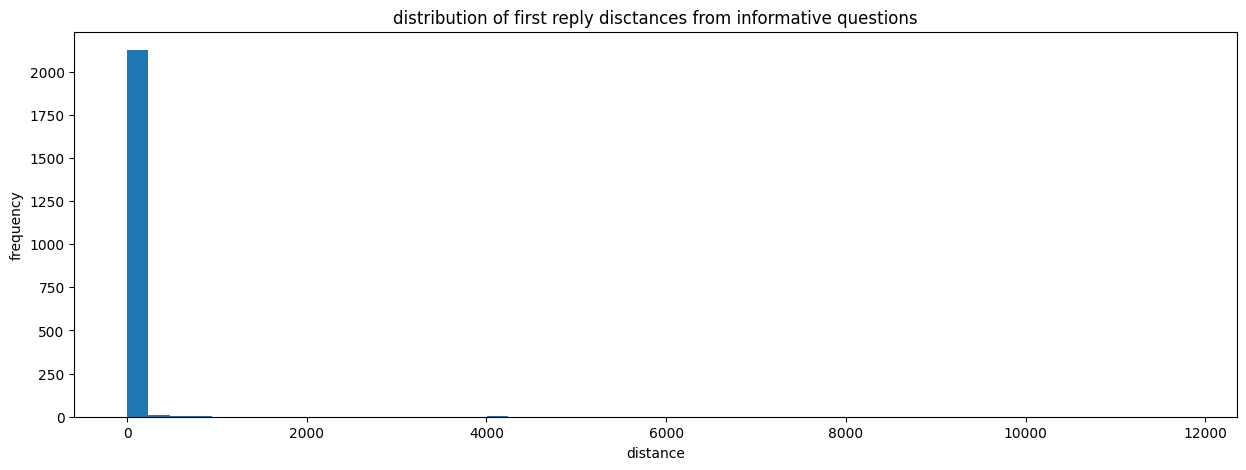

In [435]:
plt.subplots(figsize=(15, 5))
plt.hist(first_dist, bins=50)
plt.title('distribution of first reply disctances from informative questions')
plt.xlabel('distance')
plt.ylabel('frequency')
plt.show()

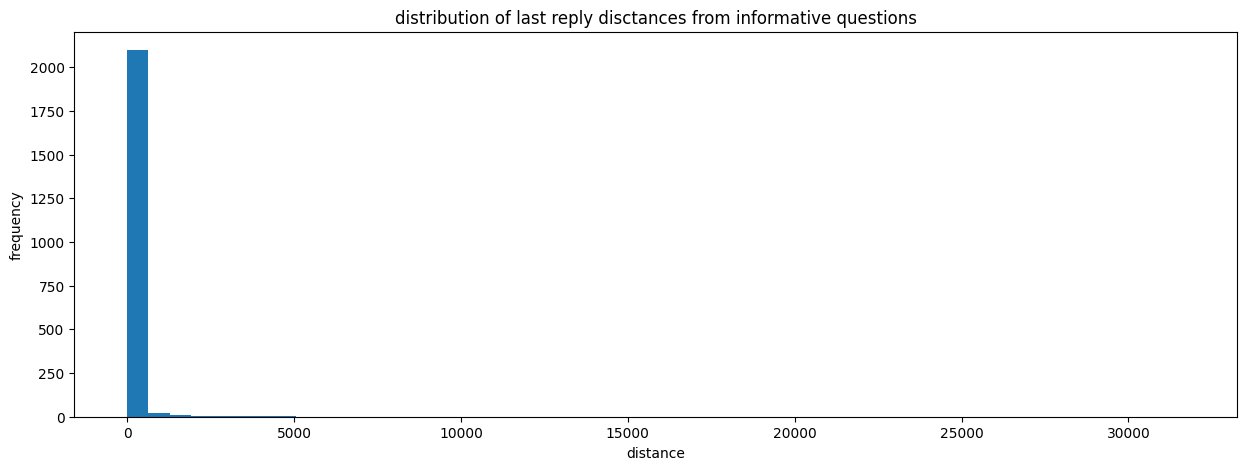

In [439]:
plt.subplots(figsize=(15, 5))
plt.hist(last_dist, bins=50)
plt.title('distribution of last reply disctances from informative questions')
plt.xlabel('distance')
plt.ylabel('frequency')
plt.show()

In [344]:
df_count_replies['first_reply_dist'].describe()

count     2149.000000
mean        20.821312
std        293.783184
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max      11765.000000
Name: first_reply_dist, dtype: float64

In [346]:
df_count_replies['last_reply_dist'].describe()

count     2149.000000
mean       105.776640
std        959.104157
min          1.000000
25%          2.000000
50%          5.000000
75%         16.000000
max      31668.000000
Name: last_reply_dist, dtype: float64

## Other tasks

In [383]:
has_question = {}

for message in data['messages']:
    clean = extract_text(message)
    has_question[message['id']] = ('?' in clean)

question_to_replies_ids = {message_id: [] for message_id in has_question if has_question[message_id]}
no_question_to_replies_ids = {message_id: [] for message_id in has_question if not has_question[message_id]}

for message in data['messages']:
    prev_id = message.get('reply_to_message_id')
    if prev_id is None:
        continue
    if prev_id in question_to_replies_ids:
        question_to_replies_ids[prev_id].append(message['id'])
    elif prev_id in no_question_to_replies_ids:
        no_question_to_replies_ids[prev_id].append(message['id'])

In [387]:
no_question_to_replies_ids

{1: [],
 2: [],
 3: [],
 4: [],
 5: [],
 7: [],
 8: [],
 9: [],
 10: [11],
 11: [],
 13: [],
 15: [16],
 16: [],
 17: [],
 19: [],
 20: [],
 21: [],
 22: [],
 23: [],
 24: [],
 25: [],
 26: [],
 27: [],
 28: [],
 29: [],
 31: [],
 32: [36],
 35: [39],
 36: [40],
 37: [38],
 38: [],
 40: [43],
 41: [],
 42: [],
 43: [],
 44: [],
 45: [],
 46: [],
 47: [],
 48: [],
 49: [],
 50: [51],
 51: [],
 53: [],
 54: [],
 55: [],
 56: [],
 57: [],
 58: [],
 59: [],
 61: [],
 62: [],
 63: [],
 65: [],
 66: [],
 67: [68],
 68: [],
 69: [],
 70: [],
 71: [],
 73: [],
 74: [],
 75: [78],
 76: [77],
 77: [],
 79: [],
 80: [],
 81: [],
 82: [93, 63694],
 83: [],
 84: [],
 85: [],
 86: [],
 87: [],
 88: [],
 89: [],
 90: [],
 91: [],
 92: [],
 93: [],
 95: [],
 96: [],
 97: [],
 98: [],
 99: [],
 100: [],
 102: [],
 103: [],
 104: [],
 105: [],
 106: [],
 107: [],
 108: [],
 109: [],
 110: [],
 111: [],
 112: [],
 113: [],
 114: [],
 125: [],
 126: [],
 127: [],
 129: [],
 130: [],
 131: [],
 133: [143],

In [397]:
total_replies_with_question, total_replies_without_question = 0, 0

for val in question_to_replies_ids.values():
    total_replies_with_question += len(val)

for val in no_question_to_replies_ids.values():
    total_replies_without_question += len(val)

print(f'total number of replies messages with ? : {total_replies_with_question}\ntotal number of replies messages without ? : {total_replies_without_question}')

total number of replies messages with ? : 13855
total number of replies messages without ? : 32252


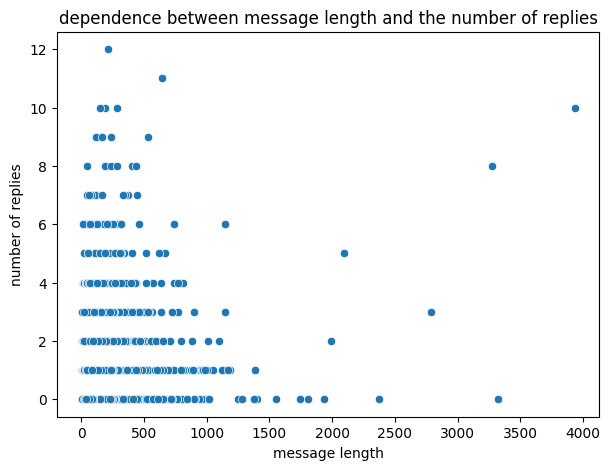

In [405]:
lenghts, reply_counts = [], []

for message in data['messages']:
    message_id = message['id']
    if message_id in question_to_replies_ids:
        text = extract_text(message)
        message_len = len(text)
        lenghts.append(message_len)
        reply_counts.append(len(question_to_replies_ids[message_id]))

plt.figure(figsize=(7, 5))
sn.scatterplot(x=lenghts, y=reply_counts)
plt.title('dependence between message length and the number of replies')
plt.xlabel('message length')
plt.ylabel('number of replies')
plt.show()

In [409]:
df['reply_count'] = df['id'].apply(lambda message_id: len(question_to_replies_ids.get(message_id, [])))

In [419]:
df_non_informative = df[df['label'] == 0]
df_non_informative.describe()

,id,label,reply_count
count,7237.000000,7237.0,7237.000000
mean,60468.907835,0.0,1.357054
std,31480.431028,0.0,0.748628
min,12.000000,0.0,1.000000
25%,31758.000000,0.0,1.000000
50%,66921.000000,0.0,1.000000
75%,87559.000000,0.0,2.000000
max,107873.000000,0.0,10.000000


In [423]:
df_informative = df[df['label'] == 1]
df_informative.describe()

,id,label,reply_count
count,2149.000000,2149.0,2149.000000
mean,59049.676128,1.0,1.877152
std,30196.708715,0.0,1.257671
min,6.000000,1.0,1.000000
25%,32124.000000,1.0,1.000000
50%,62331.000000,1.0,1.000000
75%,85130.000000,1.0,2.000000
max,107821.000000,1.0,12.000000


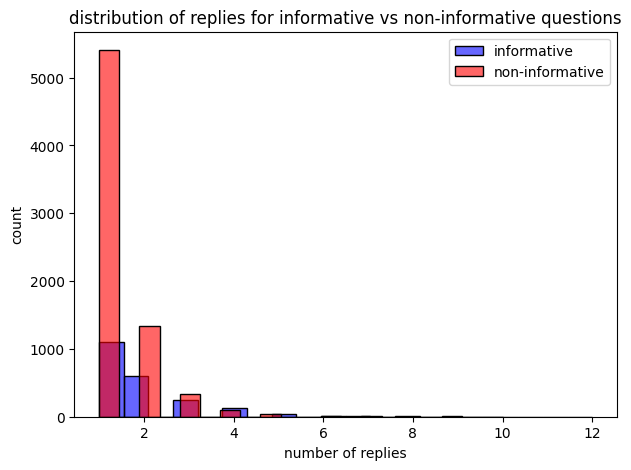

In [433]:
plt.figure(figsize=(7,5))
sn.histplot(df_informative['reply_count'], bins=20, color='blue', alpha=0.6, label='informative')
sn.histplot(df_non_informative['reply_count'], bins=20, color='red', alpha=0.6, label='non-informative')
plt.title("distribution of replies for informative vs non-informative questions")
plt.legend()
plt.xlabel("number of replies")
plt.ylabel("count")
plt.show()